# Project 1 — Markov model of breast cancer

Simulation and estimation for the multi-state model. States are coded `0..4` internally (`0`=post-surgery, `1`=local, `2`=distant, `3`=local+distant, `4`=death, absorbing).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from scipy.linalg import expm
from scipy import stats

SEED = 1
ABSORB = 4            # death state index
N_STATES = 5
LABELS = ['post-surgery', 'local', 'distant', 'local+distant', 'death']

plt.rcParams.update({'figure.figsize': (8, 4.5), 'axes.grid': True})


## Part 1 — Discrete-time model

Each step is one month; `P` holds the monthly transition probabilities.

In [3]:
P = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000, 0.0010],
    [0.0000, 0.9860, 0.0050, 0.0040, 0.0050],
    [0.0000, 0.0000, 0.9920, 0.0030, 0.0050],
    [0.0000, 0.0000, 0.0000, 0.9910, 0.0090],
    [0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
])

# sanity check: rows are probability vectors
row_sums = P.sum(1)
print('row sums =', row_sums)
assert np.allclose(row_sums, 1.0)


row sums = [1. 1. 1. 1. 1.]


### Task 1 — Lifetimes of 1000 women

A single helper walks the chain one month at a time until death. Here we use precomputed CDFs per row and compare against a uniform draw.

In [4]:
def step_cdf(P):
    """Row-wise cumulative distribution, used for inverse-CDF sampling."""
    return np.cumsum(P, axis=1)

CDF = step_cdf(P)

def walk_chain(cdf, rng, start=0):
    """Walk the DTMC to absorption; return (months, set_of_visited_states)."""
    cur, months, seen = start, 0, {start}
    while cur != ABSORB:
        cur = int(np.searchsorted(cdf[cur], rng.random()))
        months += 1
        seen.add(cur)
    return months, seen

rng = default_rng(SEED)
N = 1000
life = np.array([0]*N)
hit_local = 0
for i in range(N):
    m, seen = walk_chain(CDF, rng, start=0)
    life[i] = m
    hit_local += (1 in seen)

print('mean lifetime   : %.2f months (%.1f yr)' % (life.mean(), life.mean()/12))
print('std lifetime    : %.2f months' % life.std(ddof=1))
print('median lifetime : %.1f months' % np.median(life))
print('P(local ever)   : %.3f' % (hit_local / N))


mean lifetime   : 259.13 months (21.6 yr)
std lifetime    : 192.89 months
median lifetime : 208.0 months
P(local ever)   : 0.593


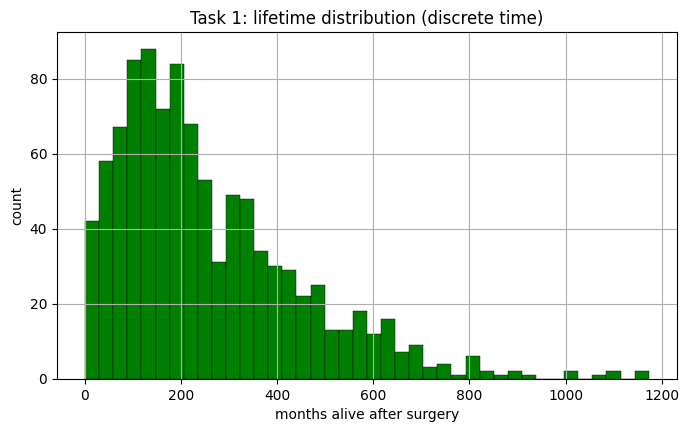

In [5]:
plt.figure()
plt.hist(life, bins=40, color="green", edgecolor='k', linewidth=0.3)

plt.xlabel('months alive after surgery')
plt.ylabel('count')
plt.title('Task 1: lifetime distribution (discrete time)')
plt.show()


### Task 2 — State occupancy at month 120

Analytic answer is the row vector $e_1 P^{120}$. We re-run the walk but stop at month 120 and tally where everyone is, then compare with a chi-square test.

In [19]:
target = 120
p0 = np.zeros(N_STATES); p0[0] = 1.0
p_analytic = p0 @ np.linalg.matrix_power(P, target)

def state_after(cdf, rng, n_steps, start=0):
    cur = start
    for _ in range(n_steps):
        if cur == ABSORB:
            break
        cur = int(np.searchsorted(cdf[cur], rng.random()))
    return cur

rng = default_rng(SEED)
where = np.array([state_after(CDF, rng, target) for _ in range(N)])
observed = np.bincount(where, minlength=N_STATES)
expected = p_analytic * N

print('analytic p120 :', np.round(p_analytic, 4))
print('expected count:', np.round(expected, 1))
print('observed count:', observed)

chi2_stat, chi2_p = stats.chisquare(observed, expected)
print('\nchi2 = %.3f, p = %.3f' % (chi2_stat, chi2_p))


analytic p120 : [0.359  0.159  0.1661 0.0677 0.2482]
expected count: [359.  159.  166.1  67.7 248.2]
observed count: [355 183 149  71 242]

chi2 = 5.751, p = 0.219


### Task 3 — Phase-type lifetime


In [7]:
P_sub = P[:ABSORB, :ABSORB]          # transient block
p_exit = P[:ABSORB, ABSORB]          # one-step death probabilities
pi0 = np.array([1.0, 0, 0, 0])

mean_theory = pi0 @ np.linalg.solve(np.eye(ABSORB) - P_sub, np.ones(ABSORB))
print('E[T] theory   = %.2f months' % mean_theory)
print('E[T] empirical= %.2f months' % life.mean())

def pmf(t):
    return pi0 @ np.linalg.matrix_power(P_sub, t - 1) @ p_exit

# binned chi-square against the phase-type pmf
bin_edges = np.unique(np.linspace(0, life.max() + 1, 21).astype(int))
counts, _ = np.histogram(life, bins=bin_edges)
horizon = int(bin_edges[-1]) + 200
masses = np.array([pmf(t) for t in range(1, horizon + 1)])
exp_bin = np.array([masses[bin_edges[k]:bin_edges[k+1]].sum()
                    for k in range(len(bin_edges) - 1)]) * N
exp_bin[-1] += N - exp_bin.sum()          # dump remaining tail mass in last bin
keep = exp_bin >= 5
chi2_pt = np.sum((counts[keep] - exp_bin[keep])**2 / exp_bin[keep])
df = keep.sum() - 1
print('\nchi2 = %.2f, df = %d, p = %.3f' % (chi2_pt, df, stats.chi2.sf(chi2_pt, df)))


E[T] theory   = 262.37 months
E[T] empirical= 259.13 months

chi2 = 15.56, df = 13, p = 0.274


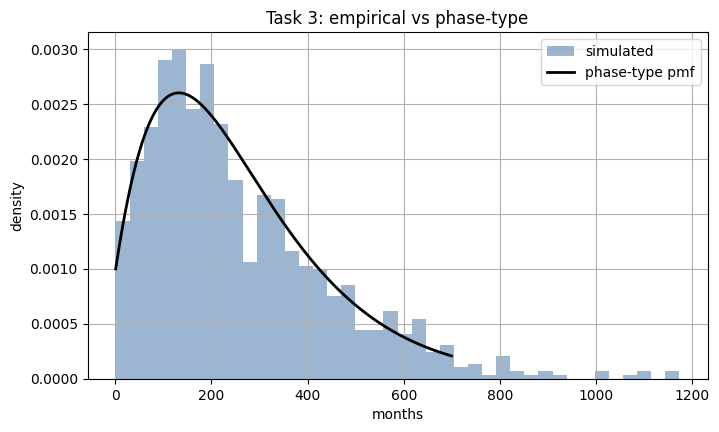

In [8]:
grid = np.arange(1, 700)
plt.figure()
plt.hist(life, bins=40, density=True, alpha=0.5, color='#3b6ea5', label='simulated')
plt.plot(grid, [pmf(t) for t in grid], color='black', lw=2, label='phase-type pmf')
plt.xlabel('months'); plt.ylabel('density')
plt.title('Task 3: empirical vs phase-type')
plt.legend(); plt.show()


### Task 4 — Conditional expected lifetime

Restrict to women who are alive at month 12 **and** had a recurrence inside the first year. Keep drawing until 1000 such women are collected (rejection sampling).

In [9]:
def walk_with_path(cdf, rng, start=0):
    cur, path = start, [start]
    while cur != ABSORB:
        cur = int(np.searchsorted(cdf[cur], rng.random()))
        path.append(cur)
    return len(path) - 1, path

def qualifies(path):
    alive_at_12 = len(path) > 12 and path[12] != ABSORB
    recurred = any(st in (1, 2, 3) for st in path[1:13])
    return alive_at_12 and recurred

rng = default_rng(SEED)
kept, tries = [], 0
while len(kept) < 1000:
    tries += 1
    m, path = walk_with_path(CDF, rng)
    if qualifies(path):
        kept.append(m)

kept = np.asarray(kept)
lo, hi = stats.t.interval(0.95, kept.size - 1, loc=kept.mean(), scale=stats.sem(kept))
print('acceptance rate : %.3f' % (len(kept) / tries))
print('conditional E[T]: %.2f months (%.1f yr)' % (kept.mean(), kept.mean()/12))
print('95%% CI          : [%.1f, %.1f]' % (lo, hi))


acceptance rate : 0.083
conditional E[T]: 176.15 months (14.7 yr)
95% CI          : [166.9, 185.4]


### Task 5 — Control variates for P(T <= 350)

Target is the fraction dead by month 350 over 100 batches of 200 women. The control variate is each batch's mean lifetime (known mean from Task 3).

In [10]:
HORIZON, BATCH, REPS = 350, 200, 100

def one_batch(cdf, rng, n=BATCH, horizon=HORIZON):
    lifetimes = np.array([walk_chain(cdf, rng)[0] for _ in range(n)])
    return (lifetimes <= horizon).mean(), lifetimes.mean()

rng = default_rng(SEED)
target_est = np.empty(REPS)     # fraction dead by 350
control = np.empty(REPS)        # batch mean lifetime
for r in range(REPS):
    target_est[r], control[r] = one_batch(CDF, rng)

cov = np.cov(target_est, control)
c_star = -cov[0, 1] / cov[1, 1]
cv_est = target_est + c_star * (control - mean_theory)

v_plain = target_est.var(ddof=1)
v_cv = cv_est.var(ddof=1)
print('plain MC : mean %.4f, var %.3e' % (target_est.mean(), v_plain))
print('with CV  : mean %.4f, var %.3e' % (cv_est.mean(), v_cv))
print('var reduction factor : %.2fx' % (v_plain / v_cv))
print('corr(target, control): %.3f' % np.corrcoef(target_est, control)[0, 1])


plain MC : mean 0.7422, var 7.668e-04
with CV  : mean 0.7396, var 2.426e-04
var reduction factor : 3.16x
corr(target, control): -0.827


## Part 2 — Continuous-time model

Now transitions happen in continuous time, governed by the rate matrix `Q`.

In [11]:
Q = np.array([
    [-0.0085, 0.0050, 0.0025, 0.0000, 0.0010],
    [ 0.0000,-0.0140, 0.0050, 0.0040, 0.0050],
    [ 0.0000, 0.0000,-0.0080, 0.0030, 0.0050],
    [ 0.0000, 0.0000, 0.0000,-0.0090, 0.0090],
    [ 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
])
print('row sums =', np.round(Q.sum(1), 12))
assert np.allclose(Q.sum(1), 0.0, atol=1e-12)


row sums = [-0. -0.  0.  0.  0.]


### Task 7 — Simulate 1000 women (continuous time)

Gillespie: draw an exponential holding time, then jump. We store jump times so we can query the state at any instant.

In [12]:
def gillespie(Q, rng, start=0):
    """Return (lifetime, times, states) for one CTMC path to absorption."""
    cur, clock = start, 0.0
    times, states = [0.0], [start]
    while cur != ABSORB:
        rate = -Q[cur, cur]
        clock += rng.exponential(1.0 / rate)
        jump = Q[cur].copy(); jump[cur] = 0.0
        cur = int(rng.choice(N_STATES, p=jump / jump.sum()))
        times.append(clock); states.append(cur)
    return clock, np.array(times), np.array(states)

def state_at(times, states, t):
    idx = np.searchsorted(times, t, side='right') - 1
    return states[idx]

rng = default_rng(SEED)
life_c = np.empty(N)
distant_by_305 = 0
for i in range(N):
    lt, tt, ss = gillespie(Q, rng)
    life_c[i] = lt
    if state_at(tt, ss, 30.5) in (2, 3):
        distant_by_305 += 1

m = life_c.mean(); s = life_c.std(ddof=1)
ci_m = stats.t.interval(0.95, N - 1, loc=m, scale=stats.sem(life_c))
# variance CI via chi-square distribution of the sample variance
lo_chi = stats.chi2.ppf(0.975, N - 1); hi_chi = stats.chi2.ppf(0.025, N - 1)
ci_s = (np.sqrt((N - 1) * s**2 / lo_chi), np.sqrt((N - 1) * s**2 / hi_chi))
print('mean : %.2f months  95%% CI [%.1f, %.1f]' % (m, *ci_m))
print('std  : %.2f months  95%% CI [%.1f, %.1f]' % (s, *ci_s))
print('distant by 30.5 mo: %.3f' % (distant_by_305 / N))


mean : 264.61 months  95% CI [252.7, 276.5]
std  : 191.57 months  95% CI [183.5, 200.4]
distant by 30.5 mo: 0.064


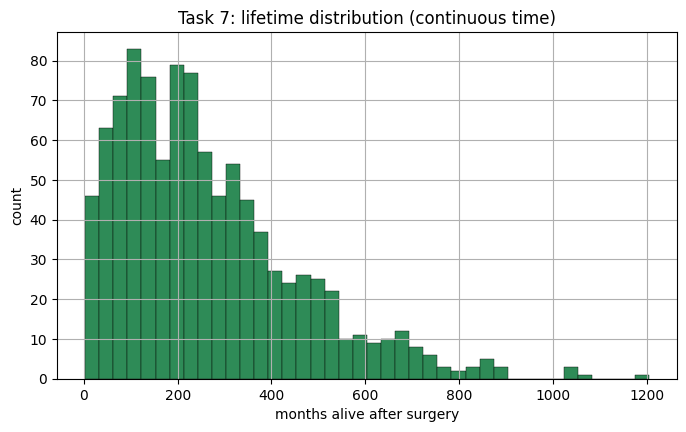

In [13]:
plt.figure()
plt.hist(life_c, bins=40, color='#2e8b57', edgecolor='k', linewidth=0.3)
plt.xlabel('months alive after surgery'); plt.ylabel('count')
plt.title('Task 7: lifetime distribution (continuous time)')
plt.show()


### Task 8 — Empirical vs theoretical CDF


KS = 0.0235, p = 0.628
matches theory


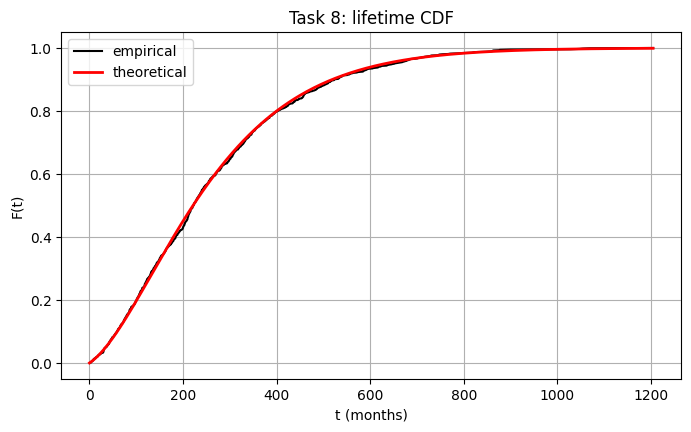

In [14]:
Q_sub = Q[:ABSORB, :ABSORB]
ones4 = np.ones(ABSORB)
pi_c = np.array([1.0, 0, 0, 0])

def cdf_theory(t):
    vals = [1.0 - pi_c @ expm(Q_sub * float(ti)) @ ones4 for ti in np.atleast_1d(t)]
    return np.array(vals)

ks_stat, ks_p = stats.kstest(life_c, cdf_theory)
print('KS = %.4f, p = %.3f' % (ks_stat, ks_p))
print('matches theory' if ks_p > 0.05 else 'deviation')

xs = np.linspace(0, life_c.max(), 400)
ecdf = np.arange(1, N + 1) / N
plt.figure()
plt.plot(np.sort(life_c), ecdf, label='empirical', color='black')
plt.plot(xs, cdf_theory(xs), color='red', lw=2, label='theoretical')
plt.xlabel('t (months)'); plt.ylabel('F(t)')
plt.title('Task 8: lifetime CDF')
plt.legend(); plt.show()


### Task 9


treatment row sums = [0. 0. 0. 0. 0.]


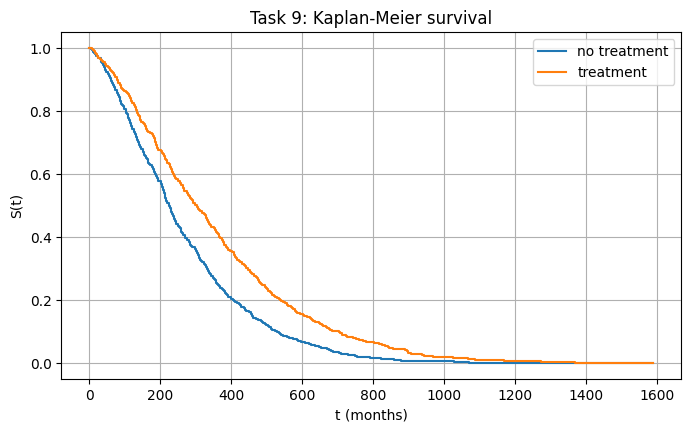

mean lifetime no-treatment: 264.6 months
mean lifetime treatment   : 350.1 months


In [15]:
Q_rx = np.array([
    [0.0, 0.00250, 0.00125, 0.000, 0.001],
    [0.0, 0.00000, 0.00000, 0.002, 0.005],
    [0.0, 0.00000, 0.00000, 0.003, 0.005],
    [0.0, 0.00000, 0.00000, 0.000, 0.009],
    [0.0, 0.00000, 0.00000, 0.000, 0.000],
])
np.fill_diagonal(Q_rx, 0.0)
for i in range(ABSORB):
    Q_rx[i, i] = -Q_rx[i].sum()
print('treatment row sums =', np.round(Q_rx.sum(1), 12))

rng = default_rng(SEED)
life_rx = np.array([gillespie(Q_rx, rng)[0] for _ in range(N)])

def km_curve(samples, grid):
    samples = np.sort(samples)
    return 1.0 - np.searchsorted(samples, grid, side='right') / samples.size

grid = np.linspace(0, max(life_c.max(), life_rx.max()), 500)
plt.figure()
plt.step(grid, km_curve(life_c, grid), where='post', label='no treatment')
plt.step(grid, km_curve(life_rx, grid), where='post', label='treatment')
plt.xlabel('t (months)'); plt.ylabel('S(t)')
plt.title('Task 9: Kaplan-Meier survival')
plt.legend(); plt.show()
print('mean lifetime no-treatment: %.1f months' % life_c.mean())
print('mean lifetime treatment   : %.1f months' % life_rx.mean())


## Part 3 — Estimation



### Task 12 — 4 year observations

sample tracks   : [[0, 0, 0, 4], [0, 4], [0, 1, 1, 1, 3, 4]]
mean track length: 7.02


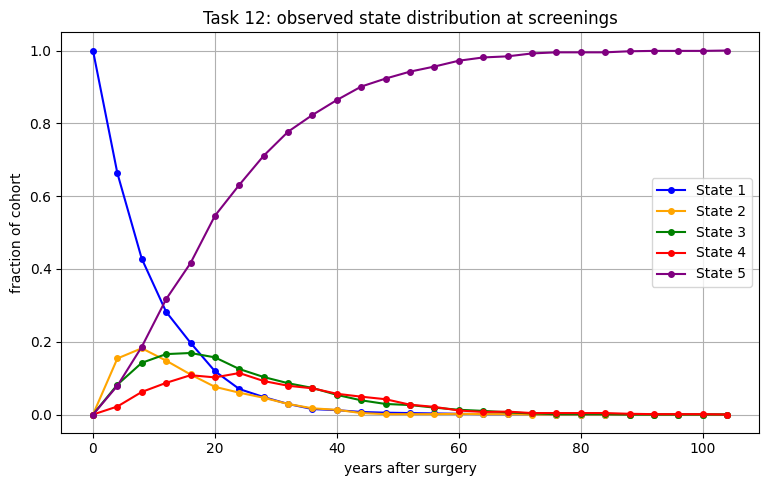

In [16]:
STEP = 48

def observed_track(Q, rng, step=STEP, start=0):
    """States seen on the 0, 48, 96, ... month grid, ending in death."""
    lt, tt, ss = gillespie(Q, rng, start)
    n_obs = int(np.ceil(lt / step))
    track = [int(state_at(tt, ss, k * step)) for k in range(n_obs)]
    track.append(ABSORB)
    return track

rng = default_rng(SEED)
tracks = [observed_track(Q, rng) for _ in range(1000)]
print('sample tracks   :', tracks[:3])
print('mean track length: %.2f' % np.mean([len(t) for t in tracks]))

# state composition at each screening, carrying death forward so columns sum to 1
K = max(len(t) for t in tracks)
share = np.zeros((N_STATES, K))
for tr in tracks:
    for k in range(K):
        st = tr[k] if k < len(tr) else ABSORB
        share[st, k] += 1
share /= len(tracks)
yr = np.arange(K) * STEP / 12.0

palette = ['blue', 'orange', 'green', 'red', 'purple']
plt.figure(figsize=(9, 5.2))
for st in range(N_STATES):
    plt.plot(yr, share[st], marker='o', ms=4, color=palette[st], label='State %d' % (st + 1))
plt.xlabel('years after surgery'); plt.ylabel('fraction of cohort')
plt.title('Task 12: observed state distribution at screenings')
plt.legend(); plt.show()


### Task 13 — Recover Q by Monte-Carlo EM

Each iteration fills in the hidden paths between screenings by rejection, then re-estimates the rates 

In [17]:
def fill_segment(Qk, rng, start, end, span, attempts=5000):
    """Rejection-sample a path on [0, span] with endpoints (start, end).
    Returns list of (duration, state) pieces, or None on failure."""
    for _ in range(attempts):
        cur, clock, pieces = start, 0.0, []
        while True:
            rate = -Qk[cur, cur]
            if rate <= 0:                       # hit an absorbing state
                pieces.append((span - clock, cur))
                done = (cur == end); break
            dt = rng.exponential(1.0 / rate)
            if clock + dt >= span:
                pieces.append((span - clock, cur))
                done = (cur == end); break
            pieces.append((dt, cur)); clock += dt
            jump = Qk[cur].copy(); jump[cur] = 0.0
            cur = int(rng.choice(N_STATES, p=jump / jump.sum()))
        if done:
            return pieces
    return None

def mc_em(tracks, Q_init, rng, step=STEP, n_iter=2, tol=1e-3, stop_early=False):
    Qk = Q_init.copy()
    deltas = []
    for it in range(n_iter):
        jumps = np.zeros((N_STATES, N_STATES))
        sojourn = np.zeros(N_STATES)
        for tr in tracks:
            for k in range(len(tr) - 1):
                a, b = tr[k], tr[k + 1]
                if a == ABSORB:
                    break
                seg = None
                while seg is None:
                    seg = fill_segment(Qk, rng, a, b, step)
                for idx, (dur, st) in enumerate(seg):
                    sojourn[st] += dur
                    if idx < len(seg) - 1:
                        jumps[st, seg[idx + 1][1]] += 1
        Q_next = np.zeros((N_STATES, N_STATES))
        for i in range(ABSORB):
            for j in range(N_STATES):
                if i != j and sojourn[i] > 0:
                    Q_next[i, j] = jumps[i, j] / sojourn[i]
            Q_next[i, i] = -Q_next[i].sum()
        delta = np.abs(Qk - Q_next).max()
        deltas.append(delta)
        Qk = Q_next
        print('iter %2d  delta = %.5e' % (it, delta))
        if stop_early and delta < tol:
            break
    return Qk, deltas

Q_start = np.array([
    [-0.020, 0.010, 0.005, 0.000, 0.005],
    [ 0.000,-0.020, 0.007, 0.007, 0.006],
    [ 0.000, 0.000,-0.010, 0.005, 0.005],
    [ 0.000, 0.000, 0.000,-0.010, 0.010],
    [ 0.000, 0.000, 0.000, 0.000, 0.000],
])

rng = default_rng(SEED)
Q_est, deltas = mc_em(tracks, Q_start, rng, n_iter=20)

np.set_printoptions(precision=5, suppress=True)
print('\nestimated Q:\n', Q_est)
print('\ntrue Q:\n', Q)
print('\n|Q_est - Q|:\n', np.abs(Q_est - Q))
print('\nmax abs error:', np.abs(Q_est - Q).max())


iter  0  delta = 1.10740e-02
iter  1  delta = 4.52867e-04
iter  2  delta = 3.36063e-04
iter  3  delta = 5.18847e-04
iter  4  delta = 6.19243e-04
iter  5  delta = 6.01593e-04
iter  6  delta = 3.18173e-04
iter  7  delta = 2.00297e-04
iter  8  delta = 3.55641e-04
iter  9  delta = 3.08232e-04
iter 10  delta = 3.52822e-04
iter 11  delta = 3.30111e-04
iter 12  delta = 2.64821e-04
iter 13  delta = 1.33868e-04
iter 14  delta = 1.82019e-04
iter 15  delta = 2.80975e-04
iter 16  delta = 3.69749e-04
iter 17  delta = 5.42229e-04
iter 18  delta = 3.11212e-04
iter 19  delta = 3.26162e-04

estimated Q:
 [[-0.00885  0.00528  0.00228  0.       0.0013 ]
 [ 0.      -0.01439  0.00522  0.00461  0.00456]
 [ 0.       0.      -0.00747  0.00316  0.00431]
 [ 0.       0.       0.      -0.00834  0.00834]
 [ 0.       0.       0.       0.       0.     ]]

true Q:
 [[-0.0085  0.005   0.0025  0.      0.001 ]
 [ 0.     -0.014   0.005   0.004   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.    

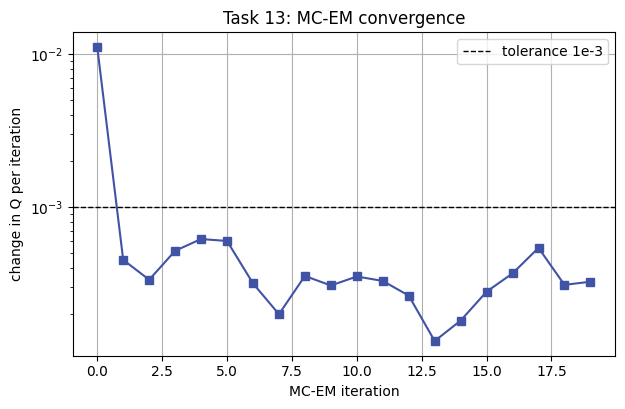

In [18]:
plt.figure(figsize=(7, 4.2))
plt.semilogy(range(len(deltas)), deltas, marker='s', color='#4053a5')
plt.axhline(1e-3, color='black', ls='--', lw=1, label='tolerance 1e-3')
plt.xlabel('MC-EM iteration'); plt.ylabel('change in Q per iteration')
plt.title('Task 13: MC-EM convergence')
plt.legend(); plt.show()


see that there is not that much improvement after first iteration. 